In [1]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/haberman.csv")








In [ ]:
df

,x1,x2,x3,Class
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1
...,...,...,...,...
301,75,62,1,1
302,76,67,0,1
303,77,65,3,1
304,78,65,1,2


In [3]:
# Features and labels
X = df.drop(["Class"], axis=1)
y = df["Class"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

#

Dataset size: 306
Train size: 244
Test size: 62


In [ ]:
df.describe()


,x1,x2,x3,Class
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [ ]:
X.columns

Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8'], dtype='object')

In [4]:
#---------------------------
# Step 3: Direct ML (for feature importance)
# ---------------------------
rf_direct = RandomForestClassifier(random_state=42)
rf_direct.fit(X_train, y_train)
y_pred_direct = rf_direct.predict(X_test)

print("\n=== Direct ML Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))




=== Direct ML Metrics ===
Accuracy: 0.6290322580645161
Precision: 0.5606275782782174
Recall: 0.6290322580645161
F1 Score: 0.5902117953730857
Confusion Matrix:
 [[38  8]
 [15  1]]


In [5]:
display(df['Class'].value_counts())

,count
Class,
1,225
2,81


In [6]:
# Compute feature importance
feature_importances = pd.Series(rf_direct.feature_importances_, index=X_train.columns)
filter_attributes = feature_importances.sort_values(ascending=False).index.tolist()
print("\nFilter attributes by importance:", filter_attributes)

#


Filter attributes by importance: ['x3', 'x1', 'x2']


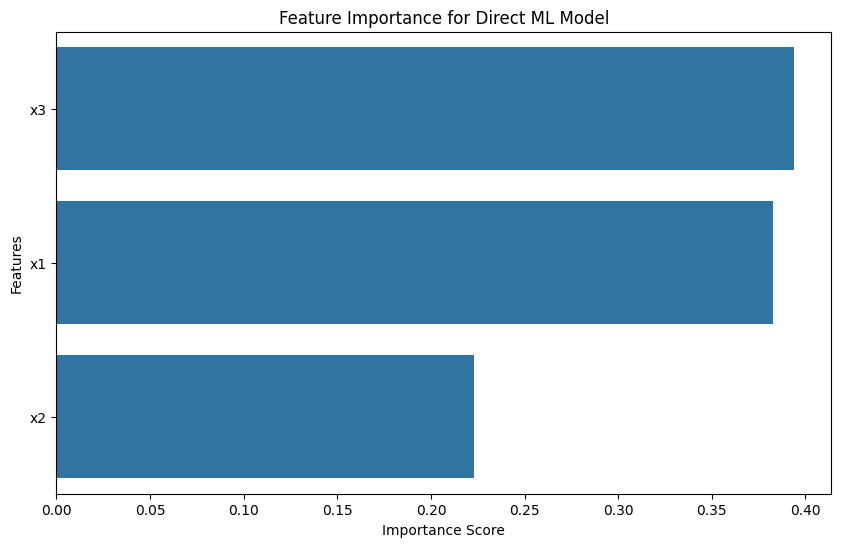

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances for visualization
feature_importances = feature_importances.sort_values(ascending=False)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance for Direct ML Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/haberman.csv")


# Features and labels
X = df.drop(["Class"], axis=1)
y = df["Class"]

# ---------------------------
# Step 2: Train/Test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset size:", len(df))
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# ---------------------------
# Step 3: Direct ML (Initial run for feature importance - for reference)
# ---------------------------
rf_direct_initial = RandomForestClassifier(random_state=42)
rf_direct_initial.fit(X_train, y_train)
importances = rf_direct_initial.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
# top_features = feat_imp.head(10).index.tolist()  # Keep top 10 features

# Use only the features specified by the user
top_features = [ 'x3', 'x1', 'x2']
print("Selected filter attributes:", top_features)


# Filter X_train and X_test to keep only top features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]


# ---------------------------
# Step 4: Direct ML (with filtered features)
# ---------------------------
rf_direct = RandomForestClassifier(n_estimators=40, random_state=42)
rf_direct.fit(X_train_filtered, y_train)
y_pred_direct = rf_direct.predict(X_test_filtered)

print("\n=== Direct ML Metrics (Filtered Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Precision:", precision_score(y_test, y_pred_direct, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_direct, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_direct, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))

# ---------------------------
# Step 5: Prepare data for Reeb graph (using filtered features)
# ---------------------------
train_df = X_train_filtered.copy()
train_df["Class"] = y_train


Dataset size: 306
Train size: 244
Test size: 62
Selected filter attributes: ['x3', 'x1', 'x2']

=== Direct ML Metrics (Filtered Features) ===
Accuracy: 0.6129032258064516
Precision: 0.5537220843672457
Recall: 0.6129032258064516
F1 Score: 0.5800881146503266
Confusion Matrix:
 [[37  9]
 [15  1]]


In [23]:


def medoid_of_group(X_group):
    """
    Return medoid index and medoid vector for a DataFrame/2D-array X_group.
    Medoid = row with minimum sum of distances to others (or to centroid if faster).
    """
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    # compute centroid then pick sample closest to centroid (fast, robust)
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]

# ---------------------------
# Step 6: Group data by target and compute centroid/medoid for each group
# ---------------------------
print("\n=== Grouping by target and computing centroids/medoids ===")

# Group by 'target'
grouped_by_target = df.groupby("Class")

centroids = grouped_by_target[top_features].mean()
print("\nCentroids by target:\n", centroids)

medoids = {}
for name, group in grouped_by_target:
    # Compute medoid for each group using the helper function
    idx, medoid_vec = medoid_of_group(group[top_features])
    medoids[name] = pd.Series(medoid_vec, index=top_features)

medoids_df = pd.DataFrame(medoids).T
print("\nMedoids by target:\n", medoids_df)

# ---------------------------
# Step 7: Create augmented features (distances to centroids and medoids)
# ---------------------------
print("\n=== Creating augmented features ===")

def add_distance_features(X_df, centroids_df, medoids_df, feature_cols):
    X_aug = X_df.copy()
    for target_class in centroids_df.index:
        centroid = centroids_df.loc[target_class, feature_cols].values
        medoid = medoids_df.loc[target_class, feature_cols].values

        # Calculate Euclidean distance to centroid
        dist_to_centroid = np.linalg.norm(X_df[feature_cols].values - centroid, axis=1)
        X_aug[f'dist_to_centroid_{target_class}'] = dist_to_centroid

        # Calculate Euclidean distance to medoid
        dist_to_medoid = np.linalg.norm(X_df[feature_cols].values - medoid, axis=1)
        X_aug[f'dist_to_medoid_{target_class}'] = dist_to_medoid
    return X_aug

X_train_augmented = add_distance_features(X_train_filtered, centroids, medoids_df, top_features)
X_test_augmented = add_distance_features(X_test_filtered, centroids, medoids_df, top_features)

print("\nAugmented training data head:\n", X_train_augmented.head())
print("\nAugmented test data head:\n", X_test_augmented.head())


# ---------------------------
# Step 8: Train and test RandomForest with augmented features
# ---------------------------
print("\n=== Training and testing RandomForest with augmented features ===")

rf_augmented = RandomForestClassifier(n_estimators=40, random_state=42)
rf_augmented.fit(X_train_augmented, y_train)
y_pred_augmented = rf_augmented.predict(X_test_augmented)

print("\n=== RandomForest Metrics (Augmented Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_augmented))
print("Precision:", precision_score(y_test, y_pred_augmented, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_augmented, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_augmented, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_augmented))


=== Grouping by target and computing centroids/medoids ===

Centroids by target:
              x3         x1         x2
Class                                
1      2.791111  52.017778  62.862222
2      7.456790  53.679012  62.827160

Medoids by target:
    x3  x1  x2
1   4  52  63
2   6  55  63

=== Creating augmented features ===

Augmented training data head:
      x3  x1  x2  dist_to_centroid_1  dist_to_medoid_1  dist_to_centroid_2  \
167  11  54  60            8.916691          7.874008            4.544250   
177  19  54  63           16.330226         15.132746           11.548965   
159   9  53  60            6.907053          5.916080            3.291716   
106  12  47  66           10.946569          9.899495            8.678529   
189   1  55  67            5.405824          5.830952            7.800496   

     dist_to_medoid_2  
167          5.916080  
177         13.038405  
159          4.690416  
106         10.440307  
189          6.403124  

Augmented test data head:

In [17]:
# ---------------------------
# Step 11: Train and test RandomForest with original + medoid distance features
# ---------------------------
print("\n=== Training and testing RandomForest with original + medoid distance features ===")

# Combine original filtered features with medoid distance features
X_train_original_medoid = pd.concat([X_train_filtered, X_train_medoid_dists], axis=1)
X_test_original_medoid = pd.concat([X_test_filtered, X_test_medoid_dists], axis=1)

rf_original_medoid = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original_medoid.fit(X_train_original_medoid, y_train)
y_pred_original_medoid = rf_original_medoid.predict(X_test_original_medoid)

print("\n=== RandomForest Metrics (Original + Medoid Distance Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_original_medoid))
print("Precision:", precision_score(y_test, y_pred_original_medoid, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_original_medoid, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_original_medoid, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_original_medoid))


=== Training and testing RandomForest with original + medoid distance features ===

=== RandomForest Metrics (Original + Medoid Distance Features) ===
Accuracy: 0.6129032258064516
Precision: 0.5221027479091995
Recall: 0.6129032258064516
F1 Score: 0.5638709677419355
Confusion Matrix:
 [[38  8]
 [16  0]]


In [18]:
X_test_original_medoid

,x3,x1,x2,dist_to_medoid_1,dist_to_medoid_2
236,0,61,68,11.045361,9.848858
228,0,60,64,9.000000,7.874008
146,0,52,61,4.472136,7.000000
142,3,52,69,6.082763,7.348469
303,3,77,65,25.099801,22.293497
...,...,...,...,...,...
24,21,38,69,22.825424,23.452079
213,3,58,58,7.874008,6.557439
288,0,70,67,18.867962,16.643317
155,0,52,68,6.403124,8.366600


In [14]:
# ---------------------------
# Step 9: Train and test RandomForest with ONLY medoid distance features
# ---------------------------
print("\n=== Training and testing RandomForest with ONLY medoid distance features ===")

# Select only the distance features from the augmented dataframes
dist_cols = [col for col in X_train_augmented.columns if 'dist_to_medoid_' in col]

X_train_medoid_dists = X_train_augmented[dist_cols]
X_test_medoid_dists = X_test_augmented[dist_cols]


rf_medoid_dists = RandomForestClassifier(n_estimators=100, random_state=42)
rf_medoid_dists.fit(X_train_medoid_dists, y_train)
y_pred_medoid_dists = rf_medoid_dists.predict(X_test_medoid_dists)

print("\n=== RandomForest Metrics (ONLY Medoid Distance Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_medoid_dists))
print("Precision:", precision_score(y_test, y_pred_medoid_dists, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_medoid_dists, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_medoid_dists, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_medoid_dists))


=== Training and testing RandomForest with ONLY medoid distance features ===

=== RandomForest Metrics (ONLY Medoid Distance Features) ===
Accuracy: 0.6774193548387096
Precision: 0.5372636262513905
Recall: 0.6774193548387096
F1 Score: 0.5992555831265508
Confusion Matrix:
 [[42  4]
 [16  0]]


In [16]:
X_train_medoid_dists

,dist_to_medoid_1,dist_to_medoid_2
167,7.874008,5.916080
177,15.132746,13.038405
159,5.916080,4.690416
106,9.899495,10.440307
189,5.830952,6.403124
...,...,...
153,4.123106,6.782330
277,15.652476,13.564660
158,4.242641,5.385165
20,16.309506,19.621417


In [15]:
# ---------------------------
# Step 10: Train and test RandomForest with ONLY centroid distance features
# ---------------------------
print("\n=== Training and testing RandomForest with ONLY centroid distance features ===")

# Select only the centroid distance features from the augmented dataframes
centroid_dist_cols = [col for col in X_train_augmented.columns if 'dist_to_centroid_' in col]

X_train_centroid_dists = X_train_augmented[centroid_dist_cols]
X_test_centroid_dists = X_test_augmented[centroid_dist_cols]

rf_centroid_dists = RandomForestClassifier(n_estimators=100, random_state=42)
rf_centroid_dists.fit(X_train_centroid_dists, y_train)
y_pred_centroid_dists = rf_centroid_dists.predict(X_test_centroid_dists)

print("\n=== RandomForest Metrics (ONLY Centroid Distance Features) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_centroid_dists))
print("Precision:", precision_score(y_test, y_pred_centroid_dists, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_centroid_dists, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_centroid_dists, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_centroid_dists))


=== Training and testing RandomForest with ONLY centroid distance features ===

=== RandomForest Metrics (ONLY Centroid Distance Features) ===
Accuracy: 0.6451612903225806
Precision: 0.5937965260545905
Recall: 0.6451612903225806
F1 Score: 0.6150807717627993
Confusion Matrix:
 [[38  8]
 [14  2]]


Where limitations show

Very high-dimensional datasets (e.g., text, images)

PCA down to 2D loses too much structure; deep embeddings may be needed before your pipeline.

Tiny datasets

SMOTE requires at least a few minority samples; oversampling may fail if groups are very small.

Perfectly balanced, linearly separable datasets

Your method may be “over-engineered” compared to simpler classifiers (like logistic regression or SVM).

Streaming or non-stationary data

Recursive binning + static medoid prototypes assume stationarity; not directly suited for evolving data without modification.